'''TASK 4·Unveiling the Android App Market (Google Play Store Analysis)
Objective: Perform a comprehensive data analysis of the Google Play Store ecosystem — cleaning messy real-world data, exploring app categories, analysing ratings and pricing trends, and conducting sentiment analysis on user reviews.'''

'''1.Load the Play Store apps dataset and the user reviews dataset separately'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px
import plotly.io as pio
pio.renderers.default= "notebook" #will help to render input/output of plotly

In [2]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize']=(12,6)

'''1.Load the Play Store apps dataset and the user reviews dataset separately.'''

In [3]:
apps_df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L2-AppMarketApps.csv")
reviews_df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L2-AppMarketUserReview.csv")

In [4]:
#seperate df dataset used
print("PlayStore Apps Dataset")
print(apps_df)
print("-"*80)
print("\n\n\nUser Reviews Dataset")
print(reviews_df)

PlayStore Apps Dataset
                                                     App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE   

    

'''2.Data cleaning: fix incorrect data types,handle nulls,remove duplicates'''

In [5]:
apps_df.drop_duplicates(subset='App',keep='first',inplace=True) #removingduplicates

In [6]:
apps_df.shape

(9660, 13)

In [7]:
apps_df['Installs']= apps_df['Installs'].astype(str).str.replace('+','').str.replace(',','')
apps_df['Installs']= pd.to_numeric(apps_df['Installs'],errors='coerce')

apps_df['Price']= apps_df['Price'].astype(str).str.replace('$','')
apps_df['Price']= pd.to_numeric(apps_df['Price'],errors='coerce')

In [8]:
def clean_size(size):
    if isinstance(size,str):
        if 'M' in size:
            return float(size.replace('M',''))
        elif 'k' in size:
            return float(size.replace('k',''))/1000
    return np.nan
apps_df['Size_MB']= apps_df['Size'].apply(clean_size)
apps_df.dropna(subset=['Rating','Category','Installs'],inplace=True)
print(f"Cleaned Dataset Shape: {apps_df.shape}") #shape of dataset after all of data-cleaning

Cleaned Dataset Shape: (8196, 14)


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_26744\2500386723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values,y=top_cats.index,palette='viridis')


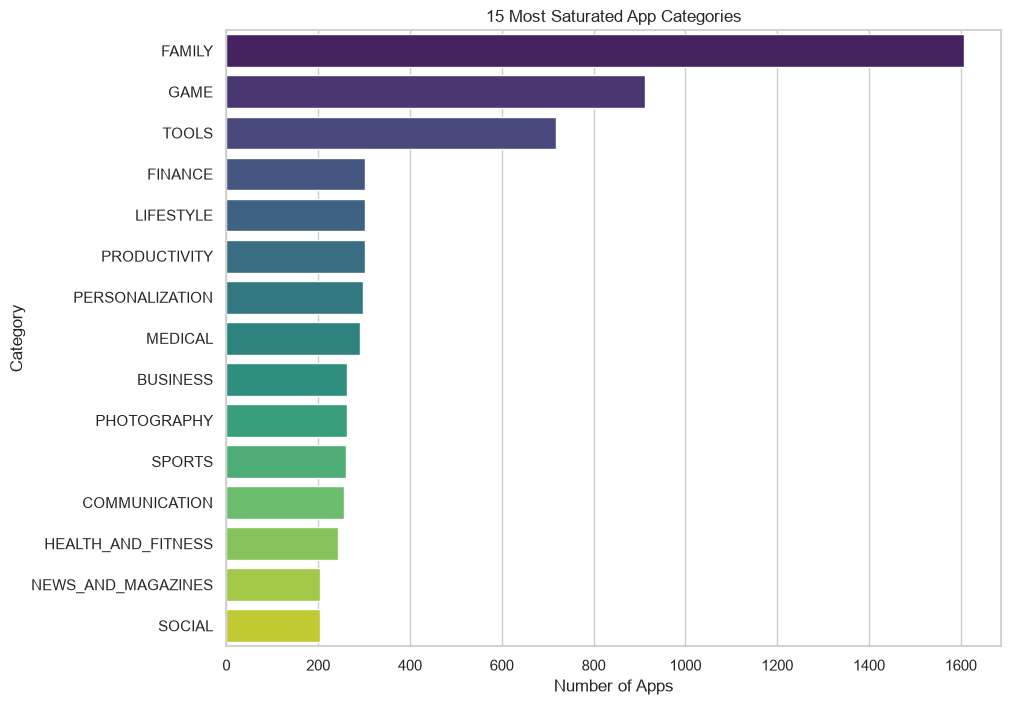

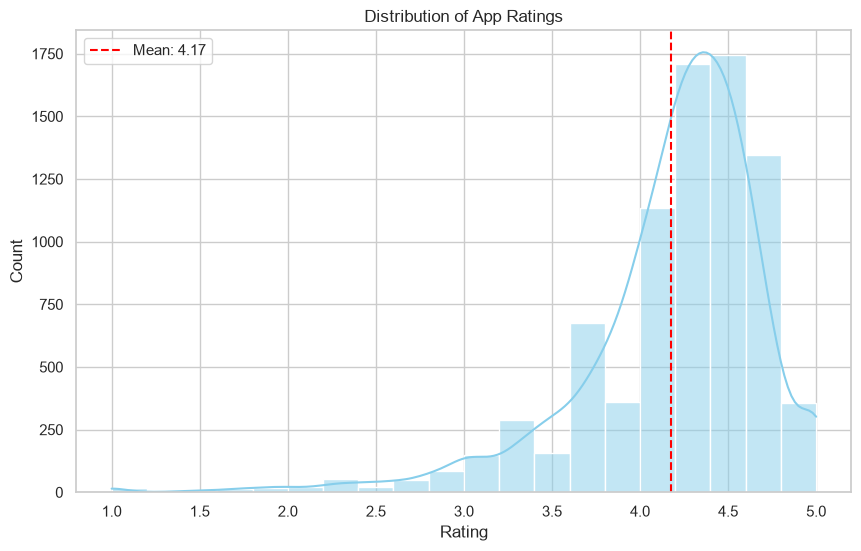

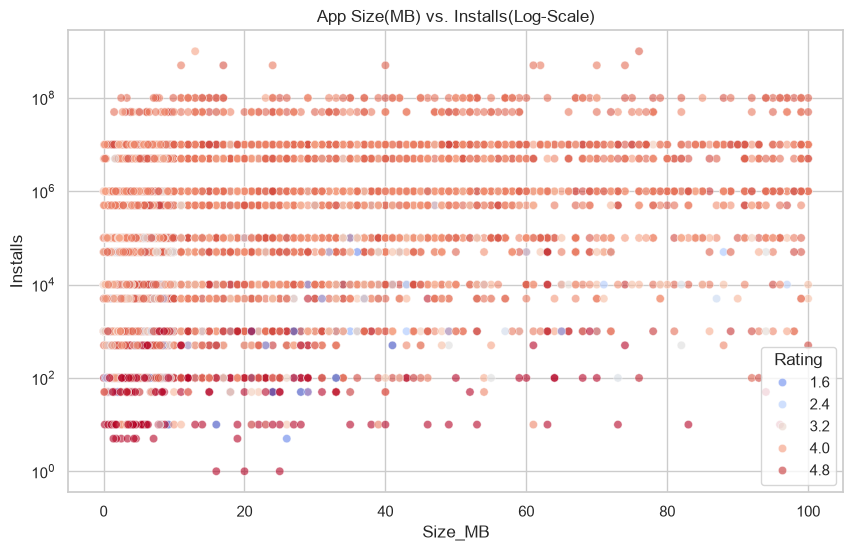

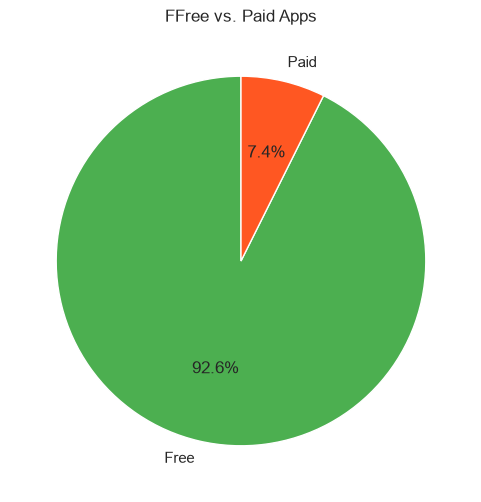

In [9]:
plt.figure(figsize=(10,8)) #A.Category Saturation
top_cats= apps_df['Category'].value_counts().head(15)
sns.barplot(x=top_cats.values,y=top_cats.index,palette='viridis')
plt.title('15 Most Saturated App Categories')
plt.xlabel('Number of Apps')
plt.show()

plt.figure(figsize=(10,6)) #B.Ratings Distribution
sns.histplot(apps_df['Rating'],bins=20,kde=True,color='skyblue')
plt.title('Distribution of App Ratings')
plt.axvline(apps_df['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {apps_df['Rating'].mean():.2f}")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6)) #C.Size vs. Installs(Log-Scale)
sns.scatterplot(data=apps_df,x='Size_MB',y='Installs',alpha=0.6,hue='Rating',palette='coolwarm')
plt.yscale('log')
plt.title('App Size(MB) vs. Installs(Log-Scale)')
plt.show()

plt.figure(figsize=(6,6)) # D.Free vs. Paid
type_counts= apps_df['Type'].value_counts()
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%',colors=['#4CAF50','#FF5722'],startangle=90)
plt.title('FFree vs. Paid Apps')
plt.show()

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_26744\1159129993.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_sample,x='Vader_Sentiment',palette='Set2')


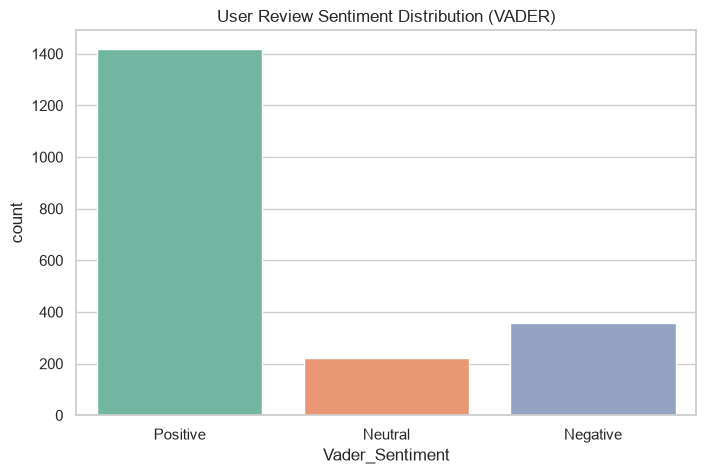

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_26744\1159129993.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sent_by_cat.values,y=sent_by_cat.index,palette='coolwarm')


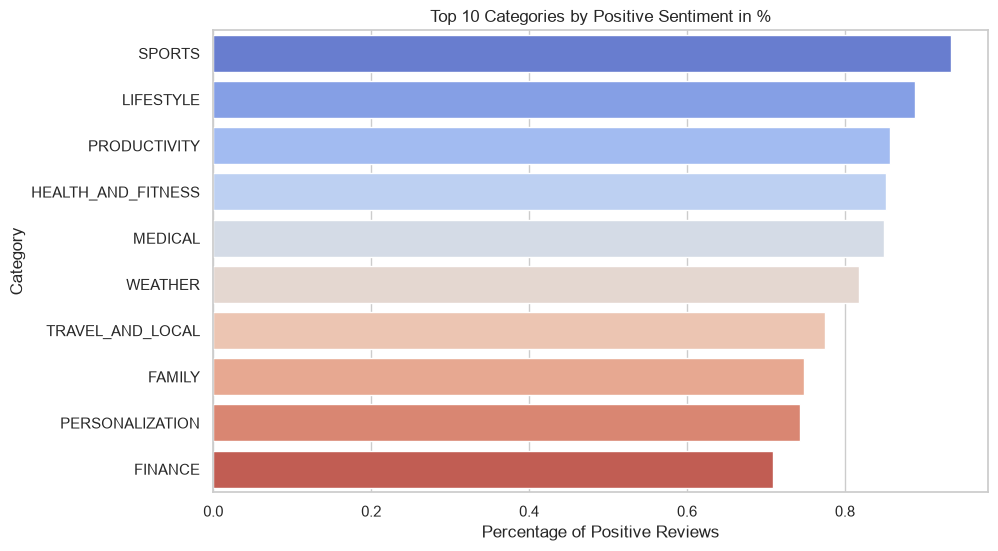

In [10]:
#i'm using VADER on User-Reviews dataset for Sentiment Analysis
analyzer=SentimentIntensityAnalyzer()
reviews_sample= reviews_df.dropna(subset=['Translated_Review']).head(2000).copy()

def get_sentiment_label(text):
    scores=analyzer.polarity_scores(str(text))
    compound=scores['compound']
    if compound>=0.05: return 'Positive'
    elif compound<=-0.05: return 'Negative'
    else: return 'Neutral'
reviews_sample['Vader_Sentiment']= reviews_sample['Translated_Review'].apply(get_sentiment_label)

plt.figure(figsize=(8,5))
sns.countplot(data=reviews_sample,x='Vader_Sentiment',palette='Set2')
plt.title('User Review Sentiment Distribution (VADER)')
plt.show()

merged_df= pd.merge(reviews_sample,apps_df[['App','Category']],on='App',how='inner') #merging sentiments with app-categories
if not merged_df.empty:
    sent_by_cat= merged_df.groupby('Category')['Vader_Sentiment'].apply(lambda x: (x=='Positive').mean()).sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=sent_by_cat.values,y=sent_by_cat.index,palette='coolwarm')
    plt.title('Top 10 Categories by Positive Sentiment in %')
    plt.xlabel('Percentage of Positive Reviews')
    plt.show()
else:
    print("Could not merge reviews with apps.")

'''9.At least one interactive visualisation using plotly'''

In [12]:
apps_df['Installs']= pd.to_numeric(apps_df['Installs'],errors='coerce')
apps_df['Reviews']= pd.to_numeric(apps_df['Reviews'],errors='coerce')
apps_df= apps_df.dropna(subset=['Installs','Reviews','Rating'])
print(f"Rows remaining: {len(apps_df)}") #shows remaning rows after drop.na()
fig= px.scatter(apps_df,x='Installs',y='Rating',color='Category',size='Reviews',hover_data=['App','Price'],title='Interactive: Installs vs Rating',log_x=True,template='plotly_white')
fig.show()

Rows remaining: 8196


'''9.Conclusion: 3 data-driven insights for a developer planning to launch a new app'''

In [13]:
print("\nDATA-DRIVEN INSIGHTS FOR DEVELOPERS:")
print("1.Market Saturation: The 'FAMILY' and 'GAME' categories are extremely crowded.Consider niche categories like 'ART_AND_DESIGN'/'EVENTS' which often have higher engagement per app.")
print("2.Pricing Strategy: Over 90% of apps are Free.A 'Freemium' model is statistically safer than a paid model.")
print("3.Sentiment Matters: Categories with high positive sentiment(e.g., 'EDUCATION') retain users better.Focus on UX and customer support to drive positive reviews,as rating alone is no longer a differentiator.")


DATA-DRIVEN INSIGHTS FOR DEVELOPERS:
1.Market Saturation: The 'FAMILY' and 'GAME' categories are extremely crowded.Consider niche categories like 'ART_AND_DESIGN'/'EVENTS' which often have higher engagement per app.
2.Pricing Strategy: Over 90% of apps are Free.A 'Freemium' model is statistically safer than a paid model.
3.Sentiment Matters: Categories with high positive sentiment(e.g., 'EDUCATION') retain users better.Focus on UX and customer support to drive positive reviews,as rating alone is no longer a differentiator.
